In [239]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import SimpleITK as sitk
import os
import pytomography
from pytomography.io.SPECT import dicom
from pytomography.projectors.SPECT import SPECTSystemMatrix
from pytomography.algorithms import OSEM
from pytomography.likelihoods import PoissonLogLikelihood
from pytomography.transforms.SPECT import SPECTAttenuationTransform, SPECTPSFTransform
from pytomography.utils import plot_utils, ESSEScatterModel, compute_EW_scatter
from pytomography.metadata.SPECT import SPECTObjectMeta, SPECTProjMeta
import json

In [240]:
current_dir = os.getcwd()
DATADIR = os.path.join(current_dir, '../../../src/pytomography/data/NIST_attenuation_data')
FILE_WATER = os.path.join(DATADIR, 'water.csv')

In [241]:
# import json
# import numpy as np
# import SimpleITK as sitk
# import torch
# import pytomography

# # 1. Chargement de l'image de labels (l'image 3D générée par Gate)
# path_labels = '../../../../simulations-kernel-esse/validation_tests/nema_final_sim/nema_voxelized.mhd'
# img_sitk = sitk.ReadImage(path_labels)
# labels_array = sitk.GetArrayFromImage(img_sitk)

# # 2. Définition des densités (extraites de ton fichier .db)
# # Unités : g/cm3
# material_densities = {
#     "IEC_PLASTIC": 1.18,
#     "G4_WATER": 1.0,
#     "G4_LUNG_ICRP": 1.04,
#     "G4_AIR": 0.00120479  # 1.20479 mg/cm3 -> g/cm3
# }


# # 3. Chargement du mapping Volume -> Label/Material
# path_volumes = '../../../../simulations-kernel-esse/validation_tests/nema_final_sim/nema_voxelized_volumes.json'
# with open(path_volumes, "r") as f:
#     volumes_mapping = json.load(f)

# # 4. Calcul du mu de l'eau à 208 keV (référence NIST)
# # mu_water_ref est en cm^-1
# mu_water_ref = pytomography.utils.get_mu_from_spectrum_interp(FILE_WATER, 208.0)

# # 5. Création de la carte de mu
# mu_map = np.zeros_like(labels_array, dtype=np.float32)

# # On parcourt chaque volume défini pour assigner sa valeur de mu
# for vol_name, info in volumes_mapping.items():
#     label = info['label']
#     material = info['material']
    
#     # mu_local = (densité_matériau / densité_eau) * mu_eau_ref
#     # On approxime ici que (mu/rho) est similaire pour ces matériaux à 208 keV
#     # sinon on peut charger chaque matériau spécifiquement
#     density_ratio = material_densities[material] / material_densities["G4_WATER"]
#     mu_val = density_ratio * mu_water_ref
    
#     mu_map[labels_array == label] = mu_val

# # 6. Conversion en Tensor pour PyTomography
# attenuation_map = torch.tensor(mu_map).to(pytomography.device)

# print(f"Carte mu générée avec succès.")
# print(f"Valeur mu Eau : {mu_water_ref:.4f} cm^-1")
# print(f"Valeur mu Plastique : {mu_map.max():.4f} cm^-1")

In [242]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(6, 5))
# slice_idx = attenuation_map.shape[0] // 2
# plt.imshow(mu_map[slice_idx], cmap='hot')
# plt.colorbar(label='linear attenuation coefficient mu (cm^-1)')
# plt.title(f"Coupe centrale de la mu-map (z={slice_idx})")
# plt.axis('off')
# plt.show()

In [243]:
def plot_mhd(mhd_path, title="Mu-Map à 208 keV", pos=[None, None, None]):
    img = sitk.ReadImage(mhd_path)
    data = sitk.GetArrayFromImage(img)
    cz, cy, cx = [s // 2 for s in data.shape]
    if pos[0] is not None:
        cz = min(pos[0], data.shape[0] - 1)
    if pos[1] is not None:
        cy = min(pos[1], data.shape[1] - 1)
    if pos[2] is not None:
        cx = min(pos[2], data.shape[2] - 1)

    # --- Définition du référentiel commun ---
    # Pour du 208 keV : 0 (Air) à 0.16 (Plastique dense)
    v_min, v_max = 0.0, 0.3

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title}\nSpacing: {img.GetSpacing()}", fontsize=14)

    views = [
        (data[cz, :, :], f"Axial (Z={cz})"),
        (data[:, cy, :], f"Coronal (Y={cy})"),
        (data[:, :, cx], f"Sagittal (X={cx})")
    ]

    for i, (slice_data, label) in enumerate(views):
        im = axes[i].imshow(slice_data, cmap='viridis', origin='lower', 
                            vmin=v_min, vmax=v_max) # <--- Échelle fixe
        axes[i].set_title(label)
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04, label="$\mu$ ($cm^{-1}$)")

    print(f"Valeur min : {data.min():.4f} cm^-1, Valeur max : {data.max():.4f} cm^-1")
    print(f"Slice où on trouve la valeur max : {np.unravel_index(np.argmax(data), data.shape)}")
    print(f"Slice où on trouve la valeur min : {np.unravel_index(np.argmin(data), data.shape)}")

    plt.tight_layout()
    plt.show()

Valeur min : 0.0001 cm^-1, Valeur max : 0.1546 cm^-1
Slice où on trouve la valeur max : (np.int64(40), np.int64(46), np.int64(43))
Slice où on trouve la valeur min : (np.int64(0), np.int64(0), np.int64(0))


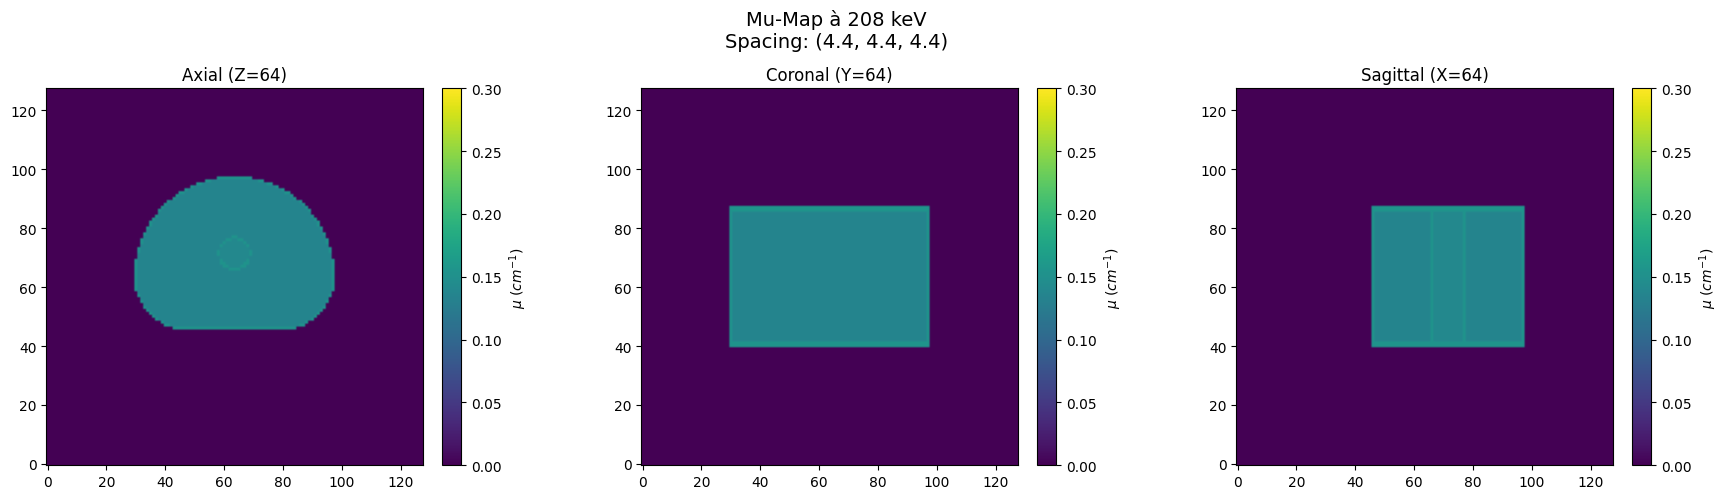

In [244]:
path_mu = "../../../../simulations-kernel-esse/validation_tests/nema_maps/nema_mu_map_208keV.mhd"
plot_mhd(path_mu, title="Mu-Map à 208 keV",pos=[None, None, None])

In [245]:
def plot_mhd(mhd_path, title="Mu-Map à 208 keV", pos=[None, None, None]):
    img = sitk.ReadImage(mhd_path)
    data = sitk.GetArrayFromImage(img)
    cz, cy, cx = [s // 2 for s in data.shape]
    if pos[0] is not None:
        cz = min(pos[0], data.shape[0] - 1)
    if pos[1] is not None:
        cy = min(pos[1], data.shape[1] - 1)
    if pos[2] is not None:
        cx = min(pos[2], data.shape[2] - 1)

    # --- Définition du référentiel commun ---
    # Pour du 208 keV : 0 (Air) à 0.16 (Plastique dense)
    v_min, v_max = 0.0, 25.0 

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title}\nSpacing: {img.GetSpacing()}", fontsize=14)

    views = [
        (data[cz, :, :], f"Axial (Z={cz})"),
        (data[:, cy, :], f"Coronal (Y={cy})"),
        (data[:, :, cx], f"Sagittal (X={cx})")
    ]

    for i, (slice_data, label) in enumerate(views):
        im = axes[i].imshow(slice_data, cmap='viridis', origin='lower', 
                            vmin=v_min, vmax=v_max) # <--- Échelle fixe
        axes[i].set_title(label)
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04, label="$\mu$ ($cm^{-1}$)")

    print(f"Valeur min : {data.min():.4f} cm^-1, Valeur max : {data.max():.4f} cm^-1")
    print(f"Slice où on trouve la valeur max : {np.unravel_index(np.argmax(data), data.shape)}")
    print(f"Slice où on trouve la valeur min : {np.unravel_index(np.argmin(data), data.shape)}")

    plt.tight_layout()
    plt.show()

Valeur min : 1.0000 cm^-1, Valeur max : 25.0000 cm^-1
Slice où on trouve la valeur max : (np.int64(75), np.int64(71), np.int64(50))
Slice où on trouve la valeur min : (np.int64(0), np.int64(0), np.int64(0))


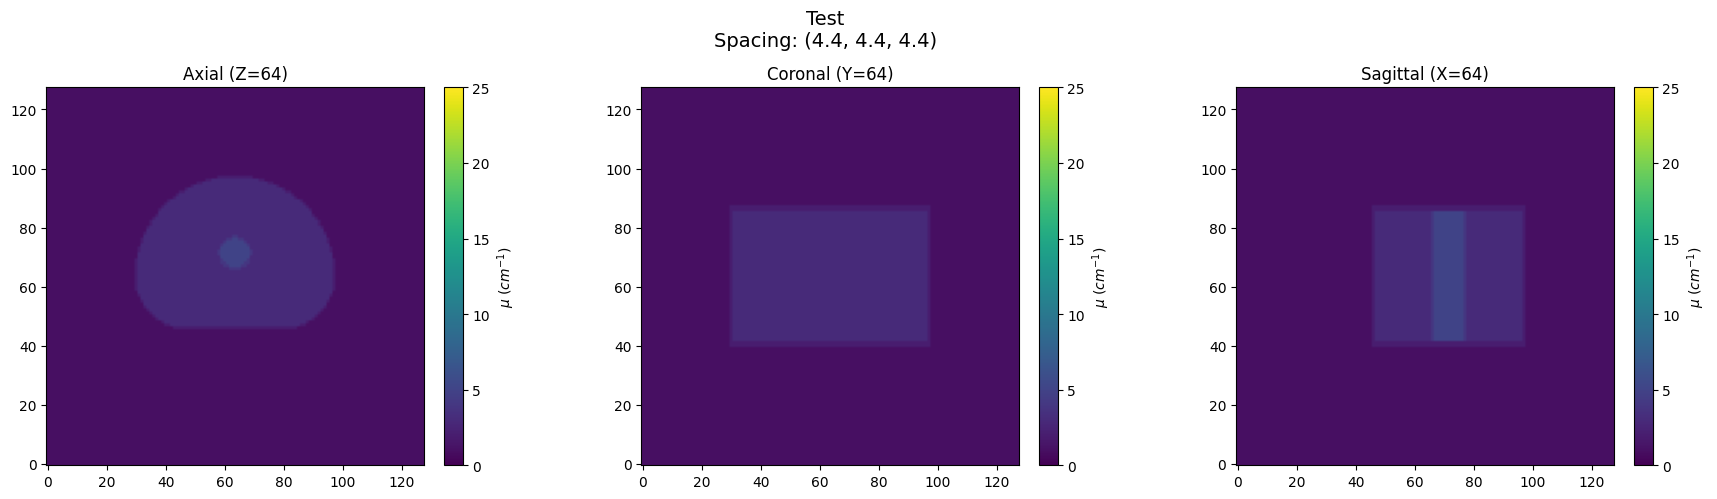

In [246]:
path_test = "../../../../simulations-kernel-esse/validation_tests/nema_maps/nema.mhd"
plot_mhd(path_test, title="Test",pos=[None, None, None])

In [247]:
config = {
    "num_projections": 5,
    "pixel_size_cm": 0.44,
    "matrix_size": 128,
    "filenames": {
        "primary": "projections_primary.mhd",
        "scatter": "projections_scatter.mhd",
        "total": "projections_total.mhd"
    },
    "raws": {
        "primary": "projections_primary.raw",
        "scatter": "projections_scatter.raw",
        "total": "projections_total.raw"
    }
}

path = '../../../../simulations-kernel-esse/validation_tests/output_spect/'
# path = '../../../../simulations-kernel-esse/validation_tests/output_spect_13042026/'
# path = '../../../../simulations-kernel-esse/validation_tests/output_spect_27042026/'

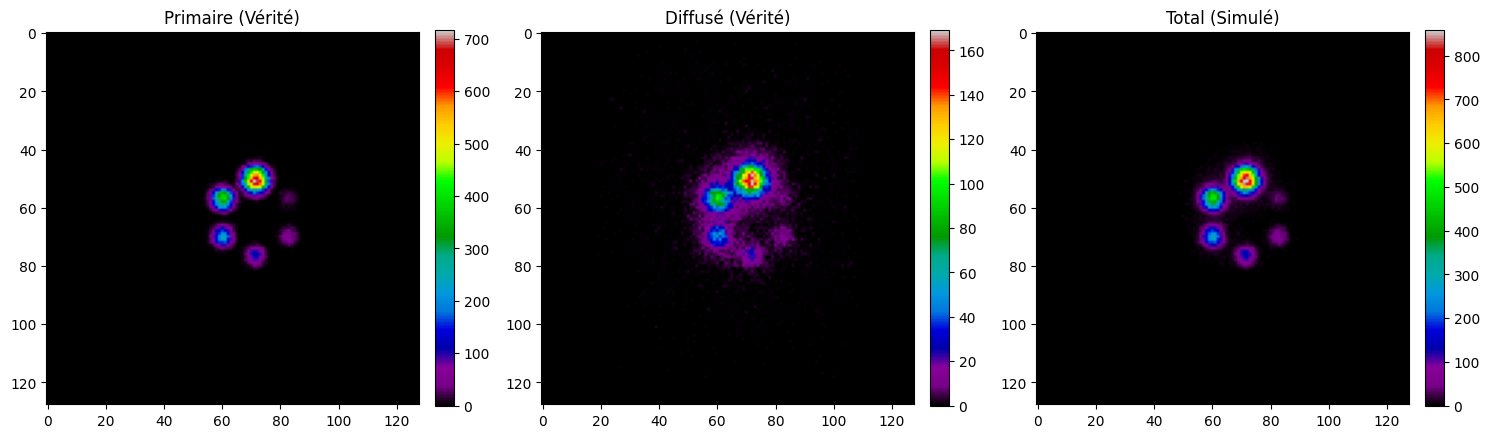

In [248]:
def load_gate_projection(filename):
    img = sitk.ReadImage(filename)
    data = sitk.GetArrayFromImage(img)
    return torch.tensor(data.astype(np.float32))

# Chargement des données
proj_primary = load_gate_projection(path + config["filenames"]["primary"])
proj_scatter = load_gate_projection(path + config["filenames"]["scatter"])
proj_total = load_gate_projection(path + config["filenames"]["total"])
# proj_primary = np.transpose(load_gate_projection(path + config["filenames"]["primary"]), (0, 2, 1))
# proj_scatter = np.transpose(load_gate_projection(path + config["filenames"]["scatter"]), (0, 2, 1))
# proj_total = np.transpose(load_gate_projection(path + config["filenames"]["total"]), (0, 2, 1))    
# proj_primary = np.transpose(load_gate_projection(path + config["filenames"]["primary"]), (2, 1, 0))
# proj_scatter = np.transpose(load_gate_projection(path + config["filenames"]["scatter"]), (2, 1, 0))
# proj_total = np.transpose(load_gate_projection(path + config["filenames"]["total"]), (2, 1, 0)) 

proj_primary = torch.flip(proj_primary, dims=[2])
proj_scatter = torch.flip(proj_scatter, dims=[2])
proj_total = torch.flip(proj_total, dims=[2])

proj_primary = proj_primary.permute(0, 2, 1)
proj_scatter = proj_scatter.permute(0, 2, 1)
proj_total = proj_total.permute(0, 2, 1)


# Affichage d'une projection (ex: angle 0)
angle_idx = 0
plt.figure(figsize=(15, 5))
titles = ['Primaire (Vérité)', 'Diffusé (Vérité)', 'Total (Simulé)']
projs = [proj_primary[angle_idx], proj_scatter[angle_idx], proj_total[angle_idx]]

for i, (p, t) in enumerate(zip(projs, titles)):
    plt.subplot(1, 3, i+1)
    plt.title(t)
    plt.imshow(p.cpu(), cmap='nipy_spectral')
    plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [249]:
def check_raw_integrity(filepath, shape=(20, 128, 128)):
    if not os.path.exists(filepath):
        print(f"Fichier introuvable : {filepath}")
        return

    # Lecture du binaire brut (float32 car MET_FLOAT dans votre mhd)
    data = np.fromfile(filepath, dtype=np.float32)
    
    print(f"--- Analyse de {os.path.basename(filepath)} ---")
    print(f"Nombre total d'éléments : {data.size}")
    print(f"Somme totale des comptes : {data.sum()}")
    print(f"Valeur Max : {data.max()}")
    print(f"Valeur Min : {data.min()}")
    print(f"Nombre de pixels non nuls : {np.count_nonzero(data)}")
    

check_raw_integrity(os.path.join(path, config["raws"]["primary"]))
check_raw_integrity(os.path.join(path, config["raws"]["scatter"]))
check_raw_integrity(os.path.join(path, config["raws"]["total"]))

--- Analyse de projections_primary.raw ---
Nombre total d'éléments : 524288
Somme totale des comptes : 1039609.0
Valeur Max : 738.0
Valeur Min : 0.0
Nombre de pixels non nuls : 20686
--- Analyse de projections_scatter.raw ---
Nombre total d'éléments : 524288
Somme totale des comptes : 580415.0
Valeur Max : 205.0
Valeur Min : 0.0
Nombre de pixels non nuls : 69943
--- Analyse de projections_total.raw ---
Nombre total d'éléments : 524288
Somme totale des comptes : 1620024.0
Valeur Max : 943.0
Valeur Min : 0.0
Nombre de pixels non nuls : 70101


In [250]:
path_data = '/home/chloe/SPECT'  # Personal computer

# pathCT = os.path.join(path_data, 'Lu177-NEMA-SymT2', 'CT')
# files_CT = [os.path.join(pathCT, file) for file in os.listdir(pathCT)]

attenuation_map_path = "../../../../simulations-kernel-esse/validation_tests/nema_maps/nema_mu_map_208keV.mhd"

img = sitk.ReadImage(attenuation_map_path)
attenuation_map_np = sitk.GetArrayFromImage(img)
attenuation_map = torch.from_numpy(attenuation_map_np.astype(np.float32))
# attenuation_map = np.transpose(attenuation_map, (0, 2, 1))
# attenuation_map = torch.flip(attenuation_map, dims=[2])
attenuation_map = attenuation_map.permute(0, 2, 1)



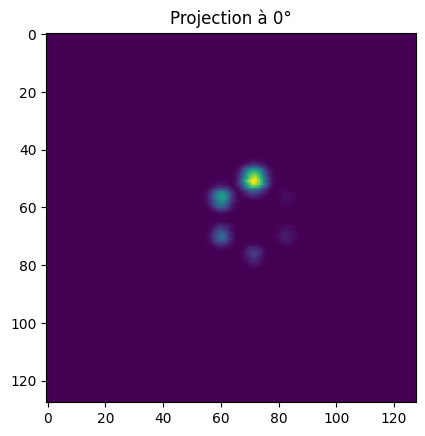

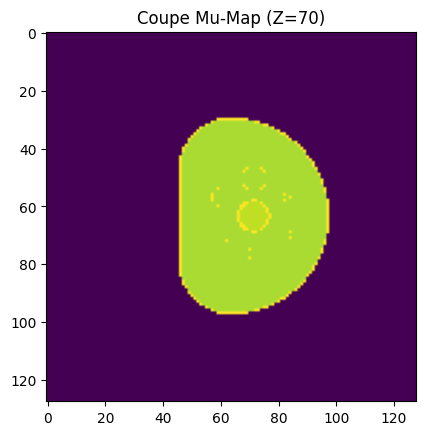

In [251]:
# Affichez la première projection (Angle 0)
plt.imshow(proj_primary[0].cpu().numpy())
plt.title("Projection à 0°")
plt.show()

# Affichez la coupe centrale de la Mu-Map correspondante
plt.imshow(attenuation_map[70].cpu().numpy())
plt.title("Coupe Mu-Map (Z=70)")
plt.show()

In [252]:
pytomography.device = 'cpu'
pytomography.dtype = torch.float32

energy = 208.0
nb_iter=10
nb_subset=8
index_peak = 0
photopeak_total = proj_total.to(pytomography.device)
photopeak_primary = proj_primary.to(pytomography.device)

In [253]:
# object_meta, proj_meta = dicom.get_metadata(file_NM)
projections = photopeak_total
projections_primary = photopeak_primary
# attenuation_map_total = dicom.get_attenuation_map_from_CT_slices(files_CT, photopeak_total)
# attenuation_map_primary = dicom.get_attenuation_map_from_CT_slices(files_CT, photopeak_primary)

# attenuation_map_total = attenuation_map
# attenuation_map_primary = attenuation_map
mu_water = pytomography.utils.get_mu_from_spectrum_interp(FILE_WATER, energy)

In [254]:

collimator_name = 'SY-ME'               #todo: automatiser la récupération du collimateur à partir des métadonnées 
energy_kev = energy
intrinsic_resolution=0.35 # todo : à vérifier ??
psf_meta = dicom.get_psfmeta_from_scanner_params(
        collimator_name,
        energy_kev,
        intrinsic_resolution=intrinsic_resolution
)
psf_transform = SPECTPSFTransform(psf_meta)

with open(path + "/metadata_pytomography.json", "r") as f:
    meta_json = json.load(f)

# Instanciation automatique
proj_meta = SPECTProjMeta(
    projection_shape=(meta_json['simulation_params']['matrix_size'], 
                      meta_json['simulation_params']['matrix_size']),
    angles=np.array(meta_json['geometry']['angles']),
    radii=np.array(meta_json['geometry']['radii_cm']),
    dr=(meta_json['simulation_params']['pixel_size_cm'], 
        meta_json['simulation_params']['pixel_size_cm'])
)
# print(proj_meta.radii)

object_meta = SPECTObjectMeta(
    dr = (meta_json['simulation_params']['pixel_size_cm'], 
          meta_json['simulation_params']['pixel_size_cm'],
          meta_json['simulation_params']['pixel_size_cm']   
    ),
    shape= (meta_json['simulation_params']['matrix_size'], 
            meta_json['simulation_params']['matrix_size'],
            meta_json['simulation_params']['matrix_size']
    )
)

In [255]:
import torch.nn.functional as F

def resample_mu_map(mu_map, object_meta):
    """
    Redimensionne la Mu-Map 3D pour correspondre à la grille de reconstruction.
    """
    # mu_map est un tenseur (Z, Y, X)
    # F.interpolate attend (Batch, Channel, Z, Y, X)
    mu_tensor = mu_map.unsqueeze(0).unsqueeze(0)
    
    # On récupère la shape cible depuis object_meta
    target_shape = object_meta.shape # ex: (128, 128, 128)
    
    # Interpolation trilinéaire
    resampled = F.interpolate(
        mu_tensor, 
        size=target_shape, 
        mode='trilinear', 
        align_corners=False
    ).squeeze()
    
    return resampled

# --- Application ---

mu_aligned = resample_mu_map(attenuation_map, object_meta)
attenuation_map_total = mu_aligned
attenuation_map_primary = mu_aligned
att_transform_total = SPECTAttenuationTransform(attenuation_map=mu_aligned)
att_transform_primary = SPECTAttenuationTransform(attenuation_map=mu_aligned)

In [256]:
# mu_aligned = torch.roll(mu_aligned, shifts=64, dims=0)  # Décale d'une demi-grille

In [257]:
system_matrix_no_correction = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_total, psf_transform],
    proj2proj_transforms=[],
    object_meta=object_meta,
    proj_meta=proj_meta
)

likelihood_no_correction = PoissonLogLikelihood(system_matrix_no_correction, photopeak_total)
algorithm_no_correction = OSEM(likelihood_no_correction)

In [258]:
recon_no_correction = algorithm_no_correction(n_iters=nb_iter, n_subsets=nb_subset)

In [259]:
system_matrix_no_scatter = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_primary, psf_transform],
    proj2proj_transforms=[],
    object_meta=object_meta,
    proj_meta=proj_meta
)

likelihood_no_scatter = PoissonLogLikelihood(system_matrix_no_scatter, photopeak_primary)
algorithm_no_scatter = OSEM(likelihood_no_scatter)

In [260]:
recon_no_scatter = algorithm_no_scatter(n_iters=nb_iter, n_subsets=nb_subset)

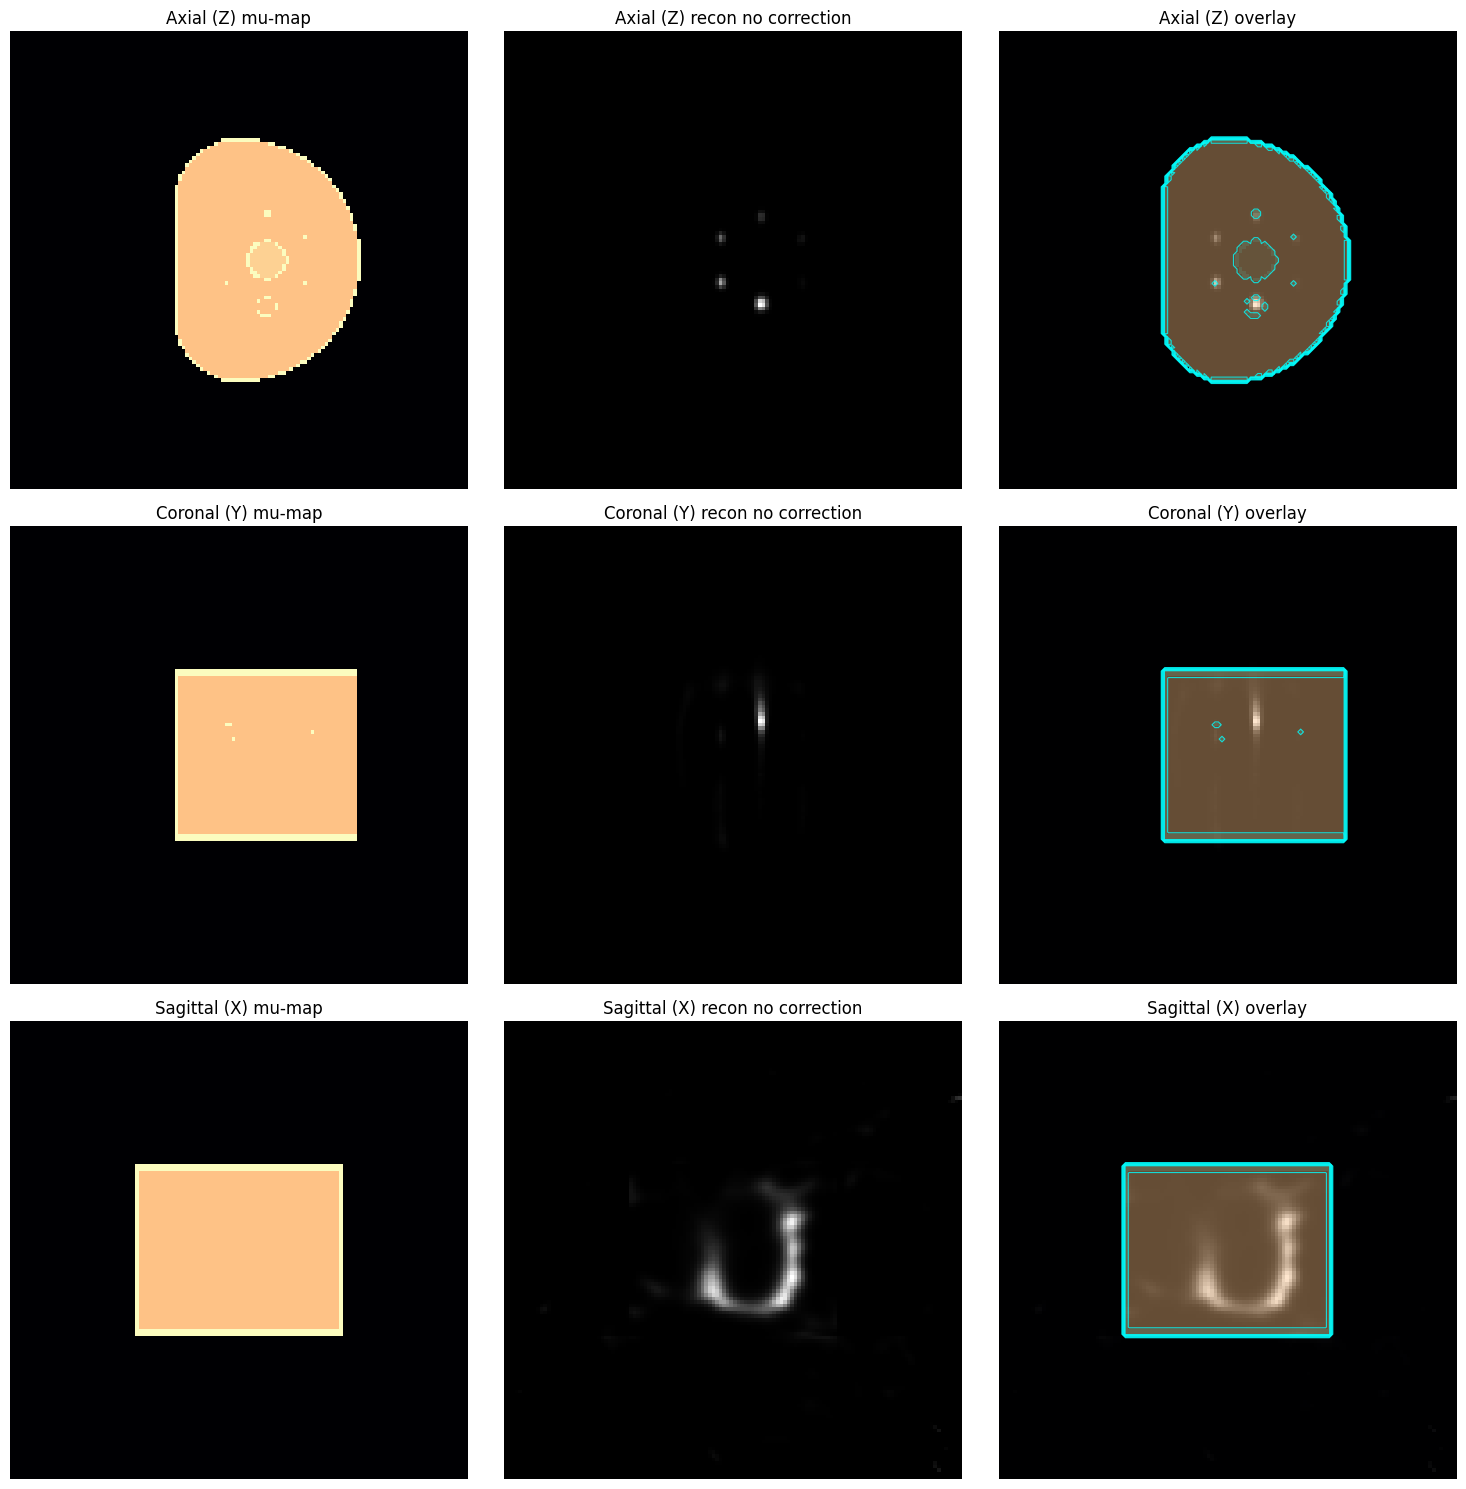

In [261]:
def _to_np(x):
    return x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)

def _norm01(img):
    img = img.astype(np.float32)
    vmin, vmax = np.percentile(img, [1, 99])
    if vmax <= vmin:
        vmin, vmax = img.min(), img.max()
    return np.clip((img - vmin) / (vmax - vmin + 1e-8), 0.0, 1.0)

mu_vol = _to_np(attenuation_map_total)
recon_vol = _to_np(recon_no_correction)

assert mu_vol.shape == recon_vol.shape, f"Shapes différentes: mu {mu_vol.shape}, recon {recon_vol.shape}"

cz, cy, cx = [s // 2 for s in mu_vol.shape]
cz = 73
cy = 71
cx = 51

# views = [
#     ("Axial (Z)", mu_vol[cz, :, :], recon_vol[cz, :, :]),
#     ("Coronal (Y)", mu_vol[:, cy, :], recon_vol[:, cy, :]),
#     ("Sagittal (X)", mu_vol[:, :, cx], recon_vol[:, :, cx]),
# ]

views = [
    ("Axial (Z)", mu_vol[cz, :, :], recon_vol[:, cy, :]),
    ("Coronal (Y)", mu_vol[:, cy, :], recon_vol[cz, :, :]),
    ("Sagittal (X)", mu_vol[:, :, cx], recon_vol[:, :, cx]),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for row, (title, mu_slice, recon_slice) in enumerate(views):
    mu_n = _norm01(mu_slice)
    recon_n = recon_slice

    axes[row, 0].imshow(mu_n, cmap="magma", origin="lower")
    axes[row, 0].set_title(f"{title} mu-map")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(recon_n, cmap="gray", origin="lower")
    axes[row, 1].set_title(f"{title} recon no correction")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(recon_n, cmap="gray", origin="lower")
    axes[row, 2].imshow(mu_n, cmap="magma", alpha=0.40, origin="lower")
    axes[row, 2].contour(mu_n, levels=6, colors="cyan", linewidths=0.8, alpha=0.8)
    axes[row, 2].set_title(f"{title} overlay")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

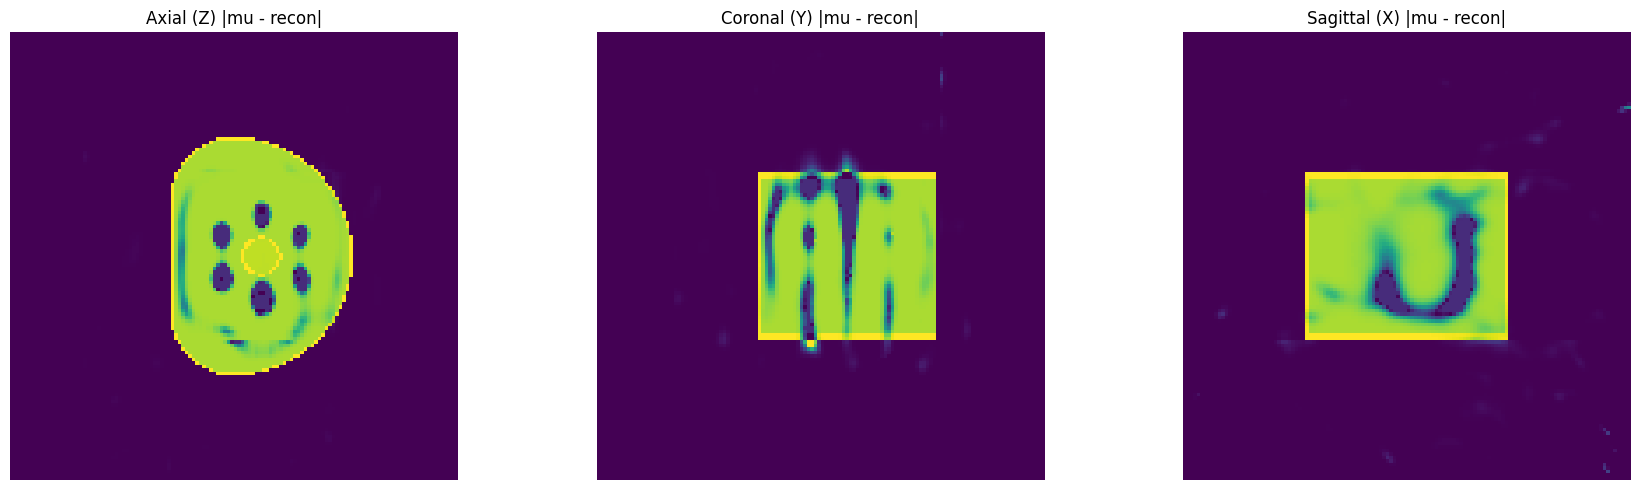

In [262]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (title, mu_slice, recon_slice) in enumerate(views):
    diff = np.abs(_norm01(mu_slice) - _norm01(recon_slice))
    axes[i].imshow(diff, cmap="viridis", origin="lower")
    axes[i].set_title(f"{title} |mu - recon|")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

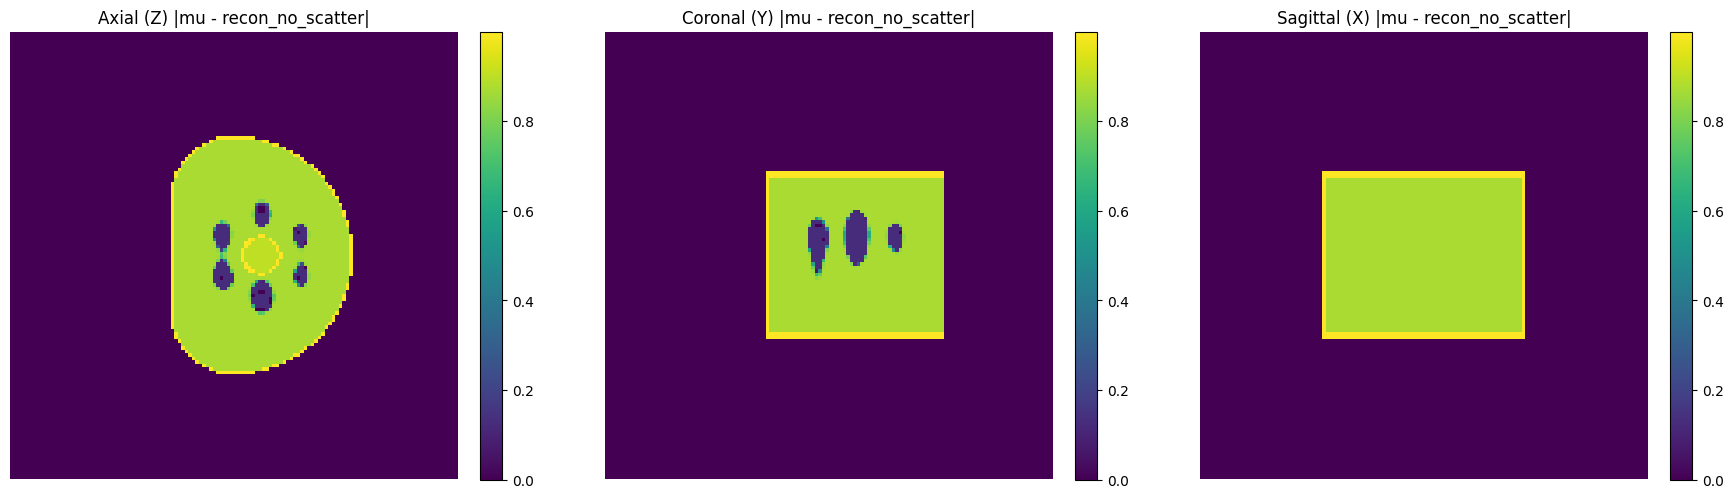

In [287]:
# Plot |mu - recon_no_scatter| for axial/coronal/sagittal
recon_ns = _to_np(recon_no_scatter)
cz, cy, cx = [s // 2 for s in mu_vol.shape]
cz = 73
cy = 71
cx = 51

views_ns = [
    ("Axial (Z)", mu_vol[cz, :, :], recon_ns[:, cy, :]),
    ("Coronal (Y)", mu_vol[:, cy, :], recon_ns[cz, :, :]),
    ("Sagittal (X)", mu_vol[:, :, cx], recon_ns[:, :, cx]),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (title, mu_slice, recon_slice) in enumerate(views_ns):
    diff = abs(_norm01(mu_slice) - _norm01(recon_slice))
    axes[i].imshow(diff, cmap="viridis", origin="lower")
    axes[i].set_title(f"{title} |mu - recon_no_scatter|")
    axes[i].axis("off")
    plt.colorbar(axes[i].imshow(diff, cmap="viridis", origin="lower"), ax=axes[i], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

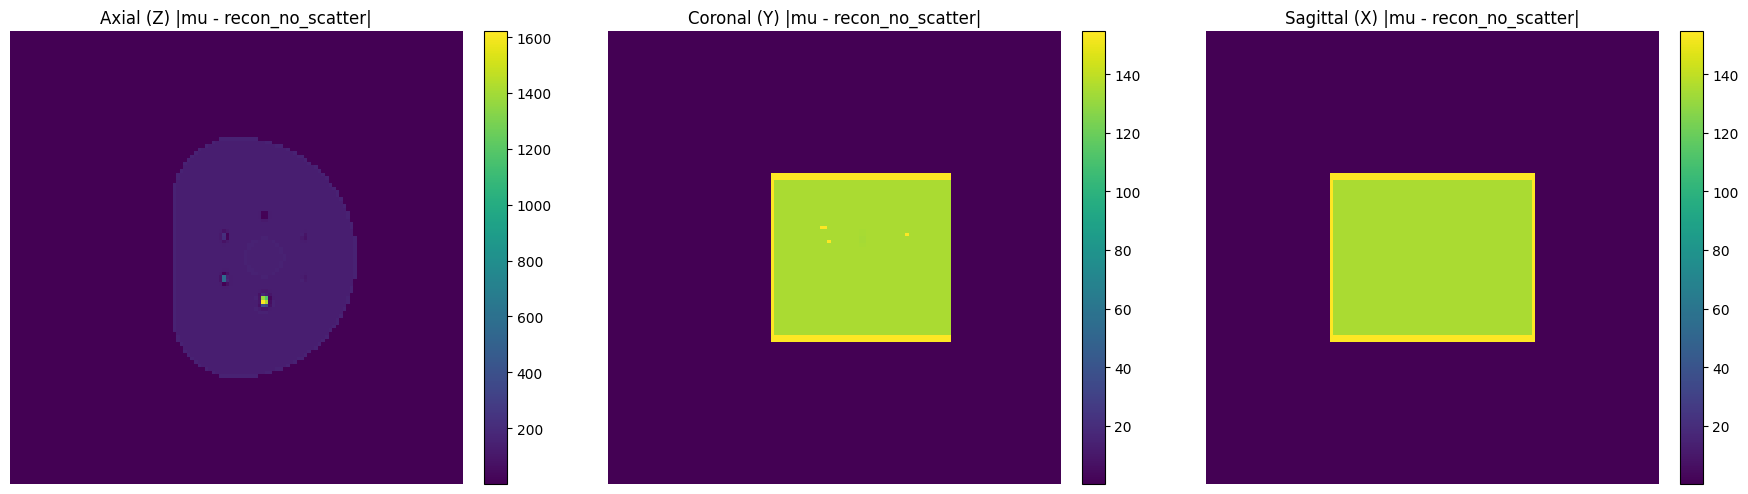

In [290]:
# Plot |mu - recon_no_scatter| for axial/coronal/sagittal
recon_ns = _to_np(recon_no_scatter)
cz, cy, cx = [s // 2 for s in mu_vol.shape]
cz = 73
cy = 71
cx = 51

views_ns = [
    ("Axial (Z)", mu_vol[cz, :, :], recon_ns[:, cy, :]),
    ("Coronal (Y)", mu_vol[:, cy, :], recon_ns[cz, :, :]),
    ("Sagittal (X)", mu_vol[:, :, cx], recon_ns[:, :, cx]),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (title, mu_slice, recon_slice) in enumerate(views_ns):
    diff = abs(1000*mu_slice - recon_slice)
    axes[i].imshow(diff, cmap="viridis", origin="lower")
    axes[i].set_title(f"{title} |mu - recon_no_scatter|")
    axes[i].axis("off")
    plt.colorbar(axes[i].imshow(diff, cmap="viridis", origin="lower"), ax=axes[i], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [264]:
proj_lower = load_gate_projection(path + "projections_scatter3.mhd").to(pytomography.device)
proj_upper = load_gate_projection(path + "projections_scatter4.mhd").to(pytomography.device)

scatter_TEW = compute_EW_scatter(
    projection_lower=proj_lower,
    projection_upper=proj_upper,
    width_lower=14.9,
    width_upper=18.66,
    width_peak=31.2,
    weighting_lower=0.5,
    weighting_upper=0.5,
    proj_meta=proj_meta,
    # sigma_r=0.48,
    # sigma_z=0.48,
    # sigma_theta=2.0
)

system_matrix_TEW = SPECTSystemMatrix(
    obj2obj_transforms=[att_transform_total, psf_transform],
    proj2proj_transforms = [],
    object_meta=object_meta,
    proj_meta=proj_meta
)

likelihood_TEW = PoissonLogLikelihood(
    system_matrix_TEW, 
    photopeak_total,
    scatter_TEW
)

algorithm_TEW = OSEM(likelihood_TEW)
recon_TEW = algorithm_TEW(n_iters=nb_iter, n_subsets=nb_subset)

In [265]:
npy_file = '../../../../simulations-kernel-esse/output/esse_kernels_3d.npy'
npy_file_amu = '../../../../simulations-kernel-esse/esse_kernels/output/esse_amu_kernels_3d.npy'

from scipy.ndimage import gaussian_filter
def get_real_esse_kernels(npy_path, npy_path_amu, grid_size):

    Z_t, Y_t, X_t = grid_size

    # --- LOAD ---
    raw_k0 = np.load(npy_path)
    raw_amu = np.load(npy_path_amu)

    # raw_k0 = gaussian_filter(raw_k0, sigma=(1.5, 0, 1.5))
    # raw_amu = gaussian_filter(raw_amu, sigma=(1.5, 0, 1.5))

    # --- FORMAT ---
    if raw_k0.ndim == 3:
        k0 = np.transpose(raw_k0, (1, 2, 0))
        amu = np.transpose(raw_amu, (1, 2, 0))
    else:
        k0 = raw_k0
        amu = raw_amu

    # --- TAYLOR TERMS ---
    K0 = k0
    K1 = k0 * amu
    K2 = 0.5 * k0 * (amu ** 2)

    def pad_kernel(data):
        Z_s, Y_s, X_s = data.shape 

        pad_z = Z_t - Z_s
        pad_y = Y_t - Y_s
        pad_x = X_t - X_s

        paddings = (
            pad_x // 2, pad_x - (pad_x // 2), # Dim X
            pad_y // 2, pad_y - (pad_y // 2), # Dim Y
            pad_z // 2, pad_z - (pad_z // 2)  # Dim Z
        )

        tensor = torch.from_numpy(data).float()
        return torch.nn.functional.pad(tensor, paddings)

    # --- APPLY PADDING ---
    k0_t = pad_kernel(K0)
    k1_t = pad_kernel(K1)
    k2_t = pad_kernel(K2)

    # --- STACK FINAL ---
    final_kernels = torch.stack([
        k0_t,
        k1_t,
        k2_t
    ])

    return final_kernels

In [266]:
# Initilization

esse = ESSEScatterModel(
    object_meta=object_meta,
    attenuation_map=attenuation_map_total,
    energy=208.4,
    mu_water=mu_water,
    kernels=get_real_esse_kernels(
        npy_path=npy_file,
        npy_path_amu=npy_file_amu,
        grid_size=object_meta.padded_shape
    )
)

system_matrix_ESSE = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_total, psf_transform],
    proj2proj_transforms = [],
    object_meta = object_meta,
    proj_meta = proj_meta,
    scatter_model=esse
)

likelihood_ESSE = PoissonLogLikelihood(system_matrix_ESSE, photopeak_total)
algorithm_ESSE = OSEM(likelihood_ESSE)

In [267]:
recon_ESSE = algorithm_ESSE(n_iters=nb_iter, n_subsets=nb_subset)

In [268]:
def plot_comparative_spect(recon1, recon2, vmax, label1, label2, slice_idx=None, coupe=2):
    if slice_idx is None:
        slice_idx = recon1.shape[-1] // 2
    vmax = vmax if vmax is not None else max(recon1.max().item(), recon2.max().item())

    recon1_CPU = recon1.cpu().numpy() if hasattr(recon1, 'is_cuda') and recon1.is_cuda else (recon1.numpy() if hasattr(recon1, 'numpy') else recon1)
    recon2_CPU = recon2.cpu().numpy() if hasattr(recon2, 'is_cuda') and recon2.is_cuda else (recon2.numpy() if hasattr(recon2, 'numpy') else recon2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    diff = recon1_CPU - recon2_CPU
    
    # RECONSTRUCTION 1
    if coupe == 0:
        im1 = axes[0].imshow(recon1_CPU[slice_idx, :, :], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
        im2 = axes[1].imshow(recon2_CPU[slice_idx, :, :], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
        im3 = axes[2].imshow(diff[slice_idx, :, :], cmap='RdBu_r', origin='lower', vmin=-vmax/2, vmax=vmax/2)
    elif coupe == 1:
        im1 = axes[0].imshow(recon1_CPU[:, slice_idx, :], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
        im2 = axes[1].imshow(recon2_CPU[:, slice_idx, :], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
        im3 = axes[2].imshow(diff[:, slice_idx, :], cmap='RdBu_r', origin='lower', vmin=-vmax/2, vmax=vmax/2)
    else:
        im1 = axes[0].imshow(recon1_CPU[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
        im2 = axes[1].imshow(recon2_CPU[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
        im3 = axes[2].imshow(diff[:, :, slice_idx], cmap='RdBu_r', origin='lower', vmin=-vmax/2, vmax=vmax/2)


    axes[0].set_title(f'{label1} ({nb_iter} iter, {nb_subset} subsets)')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], label='Intensity')

    # RECONSTRUCTION 2
    
    axes[1].set_title(f'{label2} ({nb_iter} iter, {nb_subset} subsets)')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], label='Intensity')

    # DIFFÉRENCE
    
    
    axes[2].set_title(f'Différence ({label1} - {label2})')
    axes[2].axis('off')
    plt.colorbar(im3, ax=axes[2], label='Δ Intensity')

In [269]:
slice_idx = 64
vmax = 100

No correction reconstruction value range: [0.000, 100.000]


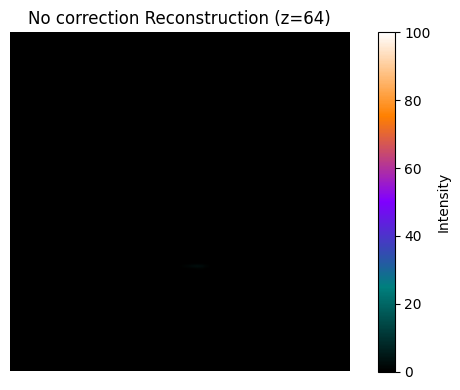

In [270]:
recon_max = recon_no_correction.max().item()
recon_min = recon_no_correction.min().item()
recon_max = vmax
print(f"No correction reconstruction value range: [{recon_min:.3f}, {recon_max:.3f}]")

SPECT_imshow_kwargs = {
    'cmap': plot_utils.pet_cmap,
    'interpolation': 'Gaussian',
    'alpha': 1,
    'vmin': recon_min,
    'vmax': recon_max,
    'zorder': 1,
    'origin': 'lower'
}

plt.figure(figsize=(6, 4))
plt.title(f'No correction Reconstruction (z={slice_idx})')
plt.imshow(recon_no_correction.cpu()[:, :, slice_idx], **SPECT_imshow_kwargs)
plt.colorbar(label='Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()

No scatter reconstruction value range: [0.000, 100.000]


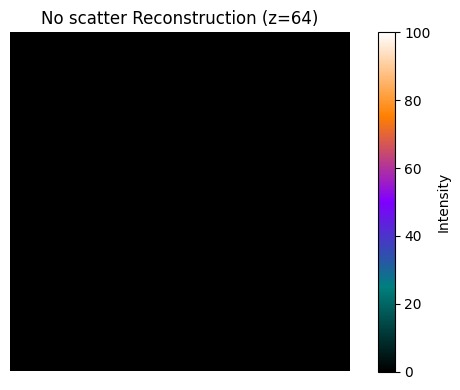

In [271]:
recon_max = recon_no_scatter.max().item()
recon_min = recon_no_scatter.min().item()
recon_max = vmax
print(f"No scatter reconstruction value range: [{recon_min:.3f}, {recon_max:.3f}]")

SPECT_imshow_kwargs = {
    'cmap': plot_utils.pet_cmap,
    'interpolation': 'Gaussian',
    'alpha': 1,
    'vmin': recon_min,
    'vmax': recon_max,
    'zorder': 1,
    'origin': 'lower'
}


plt.figure(figsize=(6, 4))
plt.title(f'No scatter Reconstruction (z={slice_idx})')
plt.imshow(recon_no_scatter.cpu()[:, :, slice_idx], **SPECT_imshow_kwargs)
plt.colorbar(label='Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()

ESSE reconstruction value range: [0.000, 100.000]


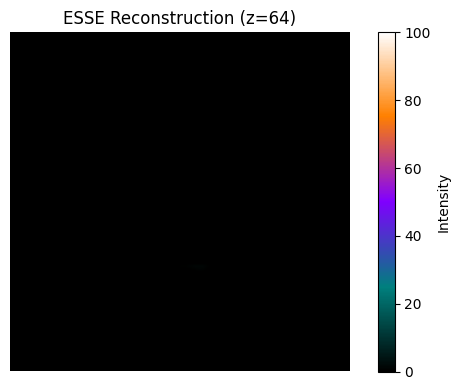

In [272]:
recon_max = recon_ESSE.max().item()
recon_min = recon_ESSE.min().item()
recon_max = vmax
print(f"ESSE reconstruction value range: [{recon_min:.3f}, {recon_max:.3f}]")

SPECT_imshow_kwargs = {
    'cmap': plot_utils.pet_cmap,
    'interpolation': 'Gaussian',
    'alpha': 1,
    'vmin': recon_min,
    'vmax': recon_max,
    'zorder': 1,
    'origin': 'lower'
}

plt.figure(figsize=(6, 4))
plt.title(f'ESSE Reconstruction (z={slice_idx})')
plt.imshow(recon_ESSE.cpu()[:, :, slice_idx], **SPECT_imshow_kwargs)
plt.colorbar(label='Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()


In [273]:
print(f"Max value in recon_no_correction: {recon_no_correction.max().item():.3f}")
print(f"Max value in recon_no_scatter: {recon_no_scatter.max().item():.3f}")
print(f"Max value in recon_ESSE: {recon_ESSE.max().item():.3f}")
print(f"Max value in recon_TEW: {recon_TEW.max().item():.3f}")

print(f"Sum of voxels in recon_no_correction: {recon_no_correction.sum().item():.2e}")
print(f"Sum of voxels in recon_no_scatter: {recon_no_scatter.sum().item():.2e}")
print(f"Sum of voxels in recon_ESSE: {recon_ESSE.sum().item():.2e}")    
print(f"Sum of voxels in recon_TEW: {recon_TEW.sum().item():.2e}")

#print la position du max recon_no_scatter dans tout le volume
max_pos_no_scatter = torch.nonzero(recon_no_scatter == recon_no_scatter.max())
print(f"Max value in recon_no_scatter is located at: {max_pos_no_scatter}")


print(f"Max value in recon_no_correction (z={slice_idx}): {recon_no_correction[:, :, slice_idx].max().item():.3f}")
print(f"Max value in recon_no_scatter (z={slice_idx}): {recon_no_scatter[:, :, slice_idx].max().item():.3f}")
print(f"Max value in recon_ESSE (z={slice_idx}): {recon_ESSE[:, :, slice_idx].max().item():.3f}")
print(f"Max value in recon_TEW (z={slice_idx}): {recon_TEW[:, :, slice_idx].max().item():.3f}")

print(f"Sum of voxels in recon_no_correction (z={slice_idx}): {recon_no_correction[:, :, slice_idx].sum().item():.2e}")
print(f"Sum of voxels in recon_no_scatter (z={slice_idx}): {recon_no_scatter[:, :, slice_idx].sum().item():.2e}")
print(f"Sum of voxels in recon_ESSE (z={slice_idx}): {recon_ESSE[:, :, slice_idx].sum().item():.2e}")    
print(f"Sum of voxels in recon_TEW (z={slice_idx}): {recon_TEW[:, :, slice_idx].sum().item():.2e}")  

Max value in recon_no_correction: 5879.734
Max value in recon_no_scatter: 7903.152
Max value in recon_ESSE: 4350.294
Max value in recon_TEW: 5955.711
Sum of voxels in recon_no_correction: 2.62e+05
Sum of voxels in recon_no_scatter: 1.74e+05
Sum of voxels in recon_ESSE: 1.69e+05
Sum of voxels in recon_TEW: 2.15e+05
Max value in recon_no_scatter is located at: tensor([[51, 69, 71]])
Max value in recon_no_correction (z=64): 3.292
Max value in recon_no_scatter (z=64): 0.001
Max value in recon_ESSE (z=64): 1.488
Max value in recon_TEW (z=64): 1.105
Sum of voxels in recon_no_correction (z=64): 7.62e+01
Sum of voxels in recon_no_scatter (z=64): 6.42e-03
Sum of voxels in recon_ESSE (z=64): 2.93e+01
Sum of voxels in recon_TEW (z=64): 2.62e+01


In [274]:
slice_idx = 64
vmax = max(recon_no_correction.max().item(), recon_no_scatter.max().item(), recon_ESSE.max().item(), recon_TEW.max().item())

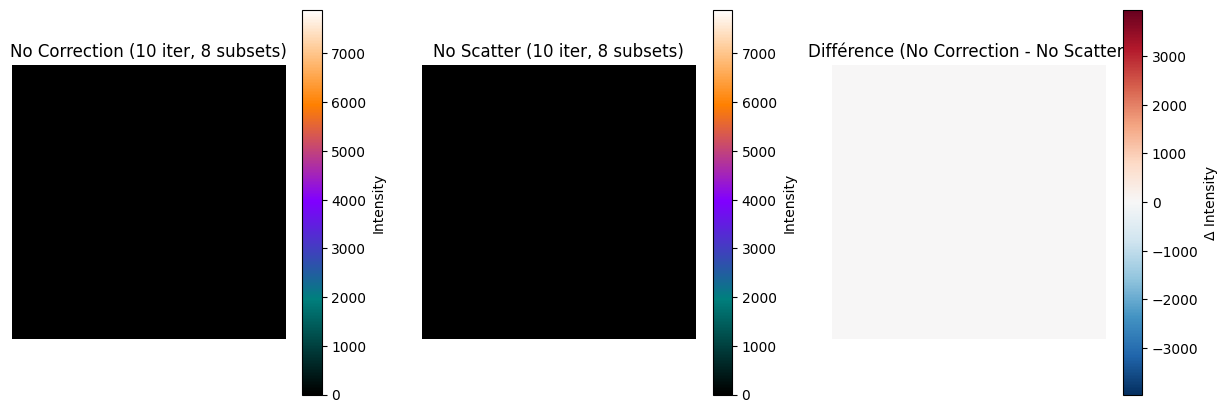

In [275]:
plot_comparative_spect(
    recon_no_correction, 
    recon_no_scatter, 
    vmax=vmax, 
    label1="No Correction", 
    label2="No Scatter", 
    slice_idx=slice_idx
)

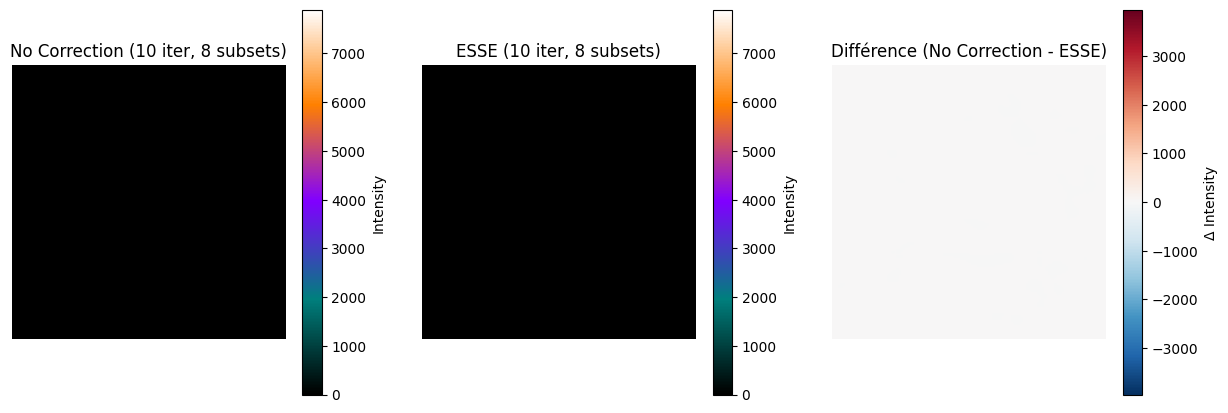

In [276]:
plot_comparative_spect(
    recon_no_correction, 
    recon_ESSE, 
    vmax=vmax, 
    label1="No Correction", 
    label2="ESSE", 
    slice_idx=slice_idx
    
)

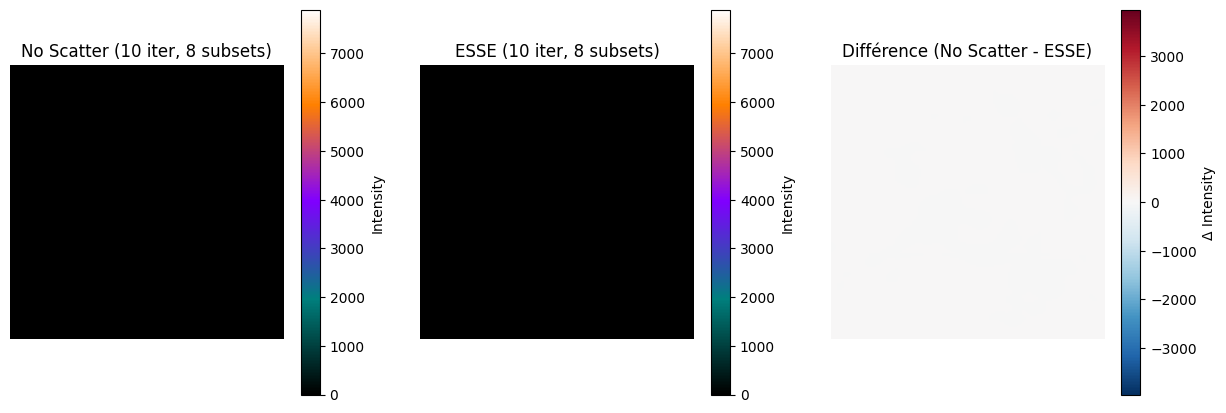

In [277]:
plot_comparative_spect(
    recon_no_scatter, 
    recon_ESSE, 
    vmax=vmax, 
    label1="No Scatter", 
    label2="ESSE", 
    slice_idx=slice_idx
)

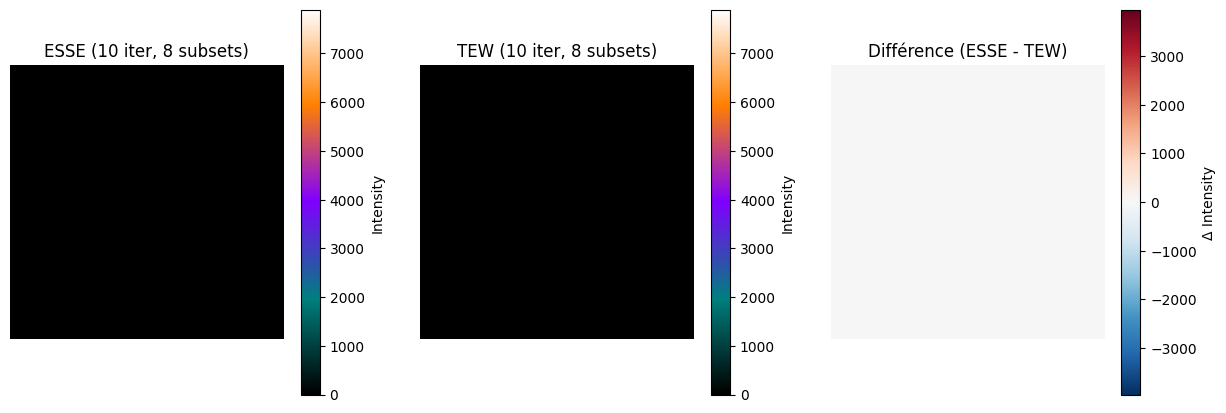

In [278]:
# Plot ESSE vs tew
plot_comparative_spect(
    recon_ESSE, 
    recon_TEW, 
    vmax=vmax, 
    label1="ESSE", 
    label2="TEW", 
    slice_idx=slice_idx
)

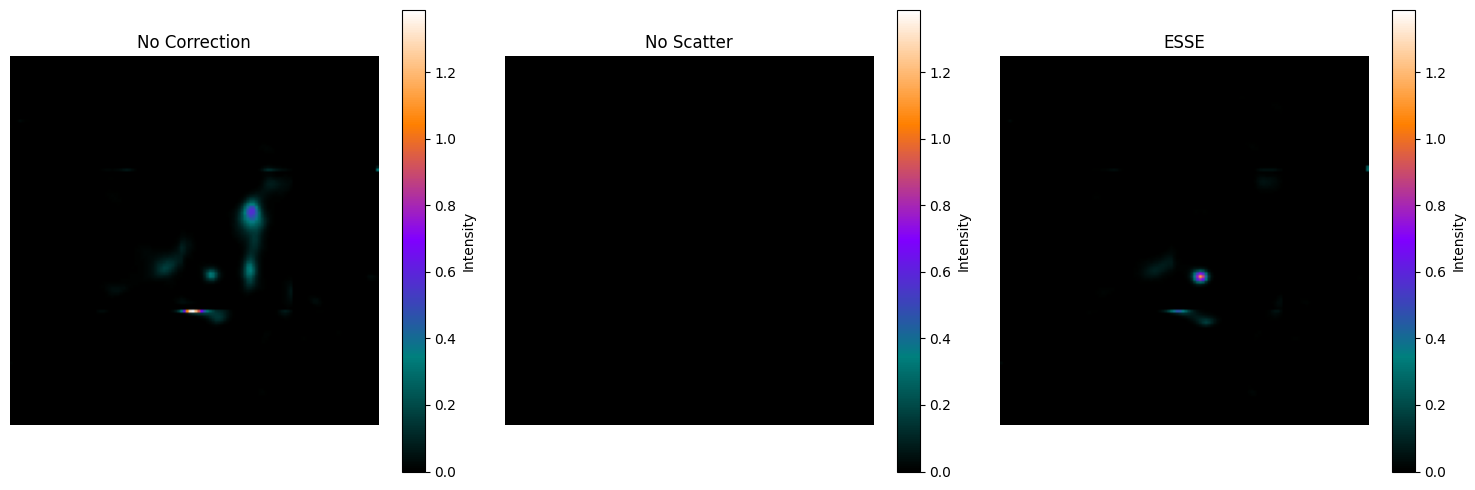

In [279]:
slice_idx = 68
vmax = max(recon_no_scatter[:, :, slice_idx].max().item(), recon_no_correction[:, :, slice_idx].max().item(), recon_ESSE[:, :, slice_idx].max().item())
# vmax = 100
plt.figure(figsize=(15, 5))
titles = ['No Correction', 'No Scatter', 'ESSE']
recons = [recon_no_correction, recon_no_scatter, recon_ESSE]
for i, (rec, title) in enumerate(zip(recons, titles)):
    plt.subplot(1, 3, i+1)
    plt.title(title)
    plt.imshow(rec.cpu()[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
    plt.colorbar(label='Intensity')
    plt.axis('off')
plt.tight_layout()
plt.show()

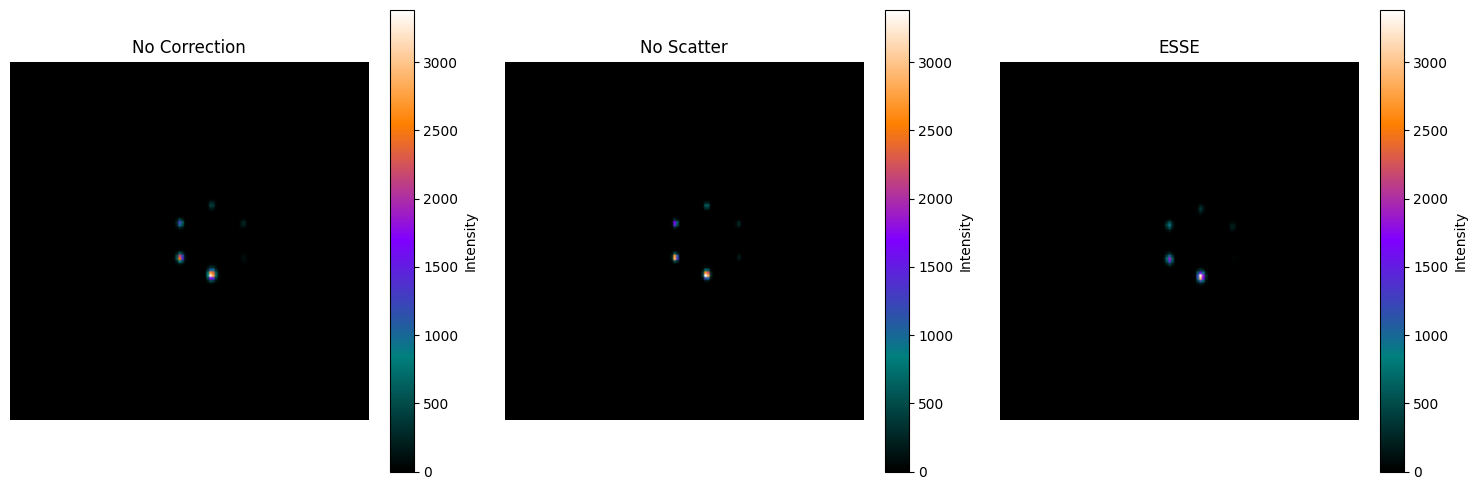

In [280]:
vmax = max(recon_no_scatter[:, slice_idx, :].max().item(), recon_no_correction[:, slice_idx, :].max().item(), recon_ESSE[:, slice_idx, :].max().item())
# vmax = 100
plt.figure(figsize=(15, 5))
titles = ['No Correction', 'No Scatter', 'ESSE']
recons = [recon_no_correction, recon_no_scatter, recon_ESSE]
for i, (rec, title) in enumerate(zip(recons, titles)):
    plt.subplot(1, 3, i+1)
    plt.title(title)
    plt.imshow(rec.cpu()[:, slice_idx, :], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
    plt.colorbar(label='Intensity')
    plt.axis('off')
plt.tight_layout()
plt.show()

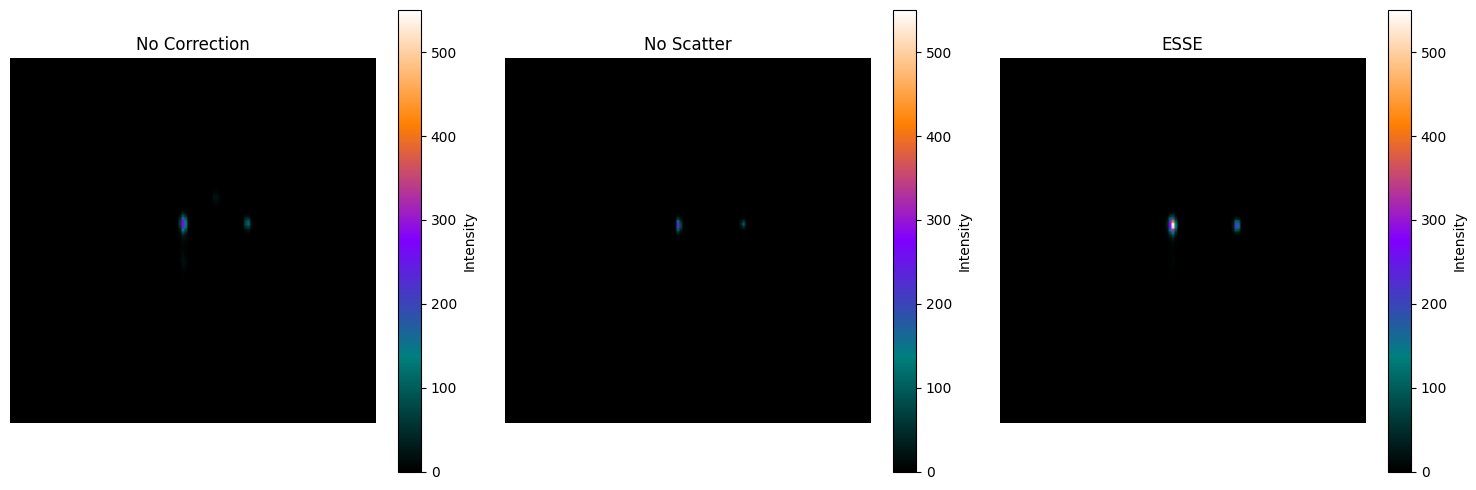

In [281]:
vmax = max(recon_no_scatter[ slice_idx, :, :].max().item(), recon_no_correction[slice_idx, :, :].max().item(), recon_ESSE[slice_idx, :, :].max().item())
# vmax = 100
plt.figure(figsize=(15, 5))
titles = ['No Correction', 'No Scatter', 'ESSE']
recons = [recon_no_correction, recon_no_scatter, recon_ESSE]
for i, (rec, title) in enumerate(zip(recons, titles)):
    plt.subplot(1, 3, i+1)
    plt.title(title)
    plt.imshow(rec.cpu()[slice_idx, :, :], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
    plt.colorbar(label='Intensity')
    plt.axis('off')
plt.tight_layout()
plt.show()

Résultats

In [282]:
from skimage.metrics import mean_squared_error, normalized_root_mse, peak_signal_noise_ratio, structural_similarity
import pandas as pd

def get_stats(image_tensor, reference_tensor):
    # Passage en numpy CPU
    img = image_tensor.detach().cpu().numpy()
    ref = reference_tensor.detach().cpu().numpy()
    
    # Définition de la plage dynamique (essentielle pour PSNR et SSIM)
    data_range = ref.max() - ref.min()
    
    mse = mean_squared_error(ref, img)
    nrmse = normalized_root_mse(ref, img)
    psnr = peak_signal_noise_ratio(ref, img, data_range=data_range)
    # SSIM sur volume 3D (peut être lent selon la taille de la matrice)
    ssim = structural_similarity(ref, img, data_range=data_range)
    
    return [mse, nrmse, psnr, ssim]

# Calcul des métriques
metrics_no_corr = get_stats(recon_no_correction, recon_no_scatter)
metrics_esse = get_stats(recon_ESSE, recon_no_scatter)
metrics_tew = get_stats(recon_TEW, recon_no_scatter)

# Présentation des résultats
df_stats = pd.DataFrame(
    [metrics_no_corr, metrics_esse, metrics_tew],
    columns=['MSE (↓)', 'NRMSE (↓)', 'PSNR (↑)', 'SSIM (↑)'],
    index=['No Correction vs Reference', 'ESSE vs Reference', 'TEW vs Reference']
)

print(df_stats.to_string())

                              MSE (↓)  NRMSE (↓)   PSNR (↑)  SSIM (↑)
No Correction vs Reference  18.522210   0.291252  65.279078  0.999888
ESSE vs Reference           89.126693   0.638891  58.455929  0.999669
TEW vs Reference            16.504523   0.274932  65.779977  0.999907


In [283]:
# stats avec get_stats, seulement pour la coupe z=62
slice_idx = 64
print(f"Stats for No Correction vs Reference (z={slice_idx}):")
stats_no_corr_slice = get_stats(recon_no_correction[:, :, slice_idx], recon_no_scatter[:, :, slice_idx])
print(f"MSE: {stats_no_corr_slice[0]:.4f}, NRMSE: {stats_no_corr_slice[1]:.4f}, PSNR: {stats_no_corr_slice[2]:.2f} dB, SSIM: {stats_no_corr_slice[3]:.4f}")     
print(f"Stats for ESSE vs Reference (z={slice_idx}):")
stats_esse_slice = get_stats(recon_ESSE[:, :, slice_idx], recon_no_scatter[:, :, slice_idx])
print(f"MSE: {stats_esse_slice[0]:.4f}, NRMSE: {stats_esse_slice[1]:.4f}, PSNR: {stats_esse_slice[2]:.2f} dB, SSIM: {stats_esse_slice[3]:.4f}") 


Stats for No Correction vs Reference (z=64):
MSE: 0.0035, NRMSE: 3966.1074, PSNR: -34.67 dB, SSIM: 0.4889
Stats for ESSE vs Reference (z=64):
MSE: 0.0010, NRMSE: 2149.5705, PSNR: -29.35 dB, SSIM: 0.5502


In [284]:
# davantage de tests statistiques, comme les tests entre les méthodes de correction et par rapport à l'original
metrics_nocor_esse = get_stats(recon_no_correction, recon_ESSE)
print(f"Comparaison No Correction vs ESSE - MSE: {metrics_nocor_esse[0]:.4f}, NRMSE: {metrics_nocor_esse[1]:.4f}, PSNR: {metrics_nocor_esse[2]:.2f} dB, SSIM: {metrics_nocor_esse[3]:.4f}") 
metrics_tew_esse = get_stats(recon_TEW, recon_ESSE)
print(f"Comparaison TEW vs ESSE - MSE: {metrics_tew_esse[0]:.4f}, NRMSE: {metrics_tew_esse[1]:.4f}, PSNR: {metrics_tew_esse[2]} dB, SSIM: {metrics_tew_esse[3]:.4f}")     
metrics_nocor_tew = get_stats(recon_no_correction, recon_TEW)
print(f"Comparaison No Correction vs TEW - MSE: {metrics_nocor_tew[0]:.4f}, NRMSE: {metrics_nocor_tew[1]:.4f}, PSNR: {metrics_nocor_tew[2]:.2f} dB, SSIM: {metrics_nocor_tew[3]:.4f}")  


Comparaison No Correction vs ESSE - MSE: 53.2838, NRMSE: 0.8023, PSNR: 55.50 dB, SSIM: 0.9995
Comparaison TEW vs ESSE - MSE: 58.8439, NRMSE: 0.8431, PSNR: 55.07335903995478 dB, SSIM: 0.9996
Comparaison No Correction vs TEW - MSE: 2.8687, NRMSE: 0.1235, PSNR: 70.92 dB, SSIM: 0.9999
